<div style="background:linear-gradient(135deg,#136a8a 0%,#267871 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">🧩&nbsp; A Reusable Template for Any PDE</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">A clean, copy-paste recipe for solving <i>your</i> PDE with a PINN. We demonstrate it on the 1-D heat equation — which has a known exact solution — so we can verify the template gives the right answer to high accuracy.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">level</span><span style="background:#e08600;color:#fff;padding:4px 8px;">intermediate</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">template · verification</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">PDE</span><span style="background:#d6336c;color:#fff;padding:4px 8px;">heat equation (exact soln)</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">~1 min · CPU</span></span></div>

Every PINN follows the same five-step skeleton. Once you internalise it, swapping in a new equation
is a one-line change to the residual. We pick the **heat equation** because its analytic solution
lets us *prove* the template works.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#recipe" style="color:#1a73e8;text-decoration:none;">1 · The 5-Step Recipe</a></li>
  <li style="margin:3px 0;"><a href="#problem" style="color:#1a73e8;text-decoration:none;">2 · The Heat Equation</a></li>
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">3 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#residual" style="color:#1a73e8;text-decoration:none;">4 · Step 1–2: Residual & Conditions</a></li>
  <li style="margin:3px 0;"><a href="#train" style="color:#1a73e8;text-decoration:none;">5 · Step 3–4: Build & Train</a></li>
  <li style="margin:3px 0;"><a href="#verify" style="color:#1a73e8;text-decoration:none;">6 · Step 5: Verify Against the Exact Solution</a></li>
  <li style="margin:3px 0;"><a href="#adapt" style="color:#1a73e8;text-decoration:none;">7 · Adapting the Template</a></li>
  </ol>
</div>

<a id="recipe"></a>

## 1 · The 5-Step Recipe

1. **Residual** — encode the PDE as `f(network) ≈ 0` using `torch.autograd`.
2. **Conditions** — express the initial & boundary conditions as extra loss terms.
3. **Build** — choose a network (`MLP` is a fine default).
4. **Train** — minimise `loss_pde + loss_ic + loss_bc`.
5. **Verify** — check residuals and, if available, an exact/reference solution.

<a id="problem"></a>

## 2 · The Heat Equation

$$\frac{\partial u}{\partial t} = \alpha\,\frac{\partial^2 u}{\partial x^2},
\qquad x\in[0,1],\; t\in[0,1],\;\; \alpha = 0.1,$$

with $u(0,x)=\sin(\pi x)$ and $u(t,0)=u(t,1)=0$. This has the **exact solution**

$$u(t,x) = \sin(\pi x)\,e^{-\alpha \pi^2 t},$$

which we'll use as ground truth.

<a id="setup"></a>

## 3 · Setup

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinn").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinn version : {pinn.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinn version : 0.1.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


<a id="residual"></a>

## 4 · Step 1–2: Residual & Conditions

In [2]:
from pinnlab.models import MLP

ALPHA = 0.1

def heat_residual(model, t, x):
    """Residual of the heat equation  u_t - alpha * u_xx."""
    t = t.clone().requires_grad_(True)
    x = x.clone().requires_grad_(True)
    u = model(torch.cat([t, x], dim=1))
    g = lambda y, v: torch.autograd.grad(y, v, torch.ones_like(y),
                                         retain_graph=True, create_graph=True)[0]
    u_t  = g(u, t)
    u_xx = g(g(u, x), x)
    return u_t - ALPHA * u_xx

def exact(t, x):
    return np.sin(np.pi * x) * np.exp(-ALPHA * np.pi**2 * t)

<a id="train"></a>

## 5 · Step 3–4: Build & Train

In [3]:
torch.manual_seed(SEED)
model = MLP(in_dim=2, hidden_layers=4, width=32, out_dim=1).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)

def sample(n, t_range=(0, 1), x_range=(0, 1)):
    t = torch.rand(n, 1, device=DEVICE) * (t_range[1]-t_range[0]) + t_range[0]
    x = torch.rand(n, 1, device=DEVICE) * (x_range[1]-x_range[0]) + x_range[0]
    return t, x

hist = []
for step in range(1, 3001):
    t, x = sample(1024)
    loss_pde = (heat_residual(model, t, x) ** 2).mean()

    x0 = torch.rand(256, 1, device=DEVICE)                                 # IC at t=0
    ic = ((model(torch.cat([torch.zeros_like(x0), x0], 1)) - torch.sin(np.pi*x0))**2).mean()

    tb = torch.rand(256, 1, device=DEVICE)                                 # BC at x=0,1
    bc = (model(torch.cat([tb, torch.zeros_like(tb)], 1))**2).mean() \
       + (model(torch.cat([tb, torch.ones_like(tb)], 1))**2).mean()

    loss = loss_pde + 10*ic + 10*bc
    opt.zero_grad(); loss.backward(); opt.step()
    hist.append(loss.item())
    if step % 1000 == 0:
        print(f"step {step:5d} | loss {loss.item():.3e}")

step  1000 | loss 5.340e-03


step  2000 | loss 1.067e-02


step  3000 | loss 2.256e-03


<a id="verify"></a>

## 6 · Step 5: Verify Against the Exact Solution

Because we know the analytic answer, we can compute a real error — the acid test that the template is correct.

Relative L2 error : 1.138e-02
Max abs error     : 1.458e-02
R^2               : 0.999487


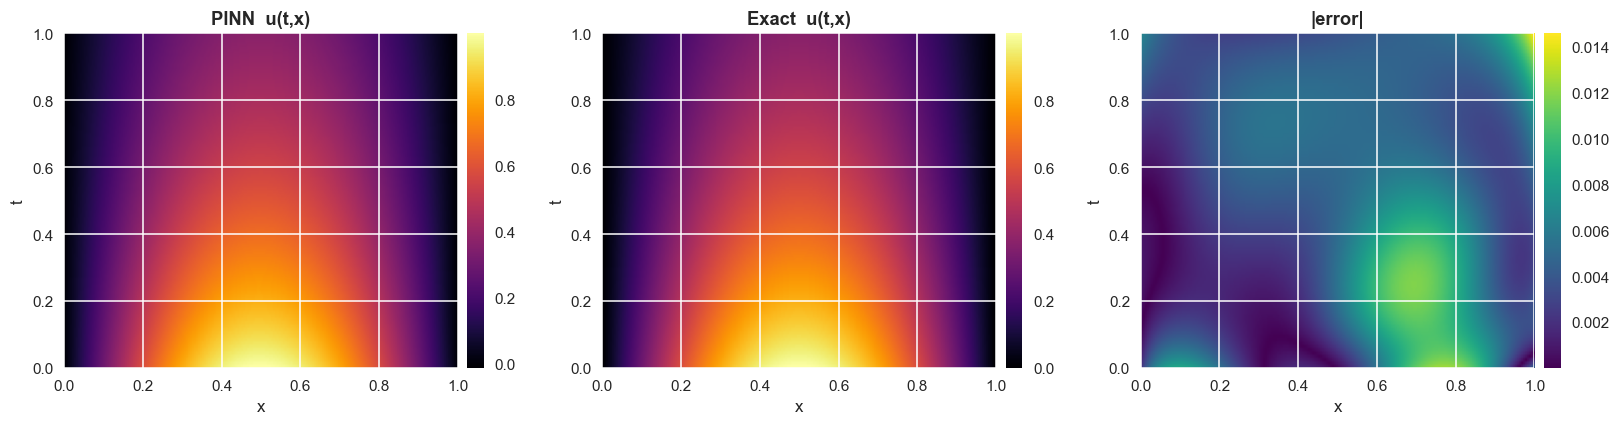

In [4]:
from pinnlab.utils.metrics import compute_error_metrics

nt, nx = 100, 200
tg = np.linspace(0, 1, nt, dtype=np.float32); xg = np.linspace(0, 1, nx, dtype=np.float32)
TT, XX = np.meshgrid(tg, xg, indexing="ij")
with torch.no_grad():
    inp = torch.tensor(np.stack([TT.ravel(), XX.ravel()], 1), dtype=torch.float32, device=DEVICE)
    U = model(inp).cpu().numpy().reshape(nt, nx)
U_exact = exact(TT, XX)

m = compute_error_metrics(U, U_exact)
rel_l2 = np.linalg.norm(U - U_exact) / np.linalg.norm(U_exact)   # global relative L2 norm
print(f"Relative L2 error : {rel_l2:.3e}")
print(f"Max abs error     : {m.max_error:.3e}")
print(f"R^2               : {m.r2_score:.6f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, data, title, cmap in [
    (ax[0], U,            "PINN  u(t,x)",  "inferno"),
    (ax[1], U_exact,      "Exact  u(t,x)", "inferno"),
    (ax[2], np.abs(U-U_exact), "|error|",  "viridis")]:
    im = a.imshow(data, extent=[0,1,0,1], origin="lower", aspect="auto", cmap=cmap)
    a.set(title=title, xlabel="x", ylabel="t"); fig.colorbar(im, ax=a, pad=0.02)
plt.tight_layout(); plt.show()

<div style="background:#e9f9ee;border-left:5px solid #1e9e54;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>✅ Tip.</b> A relative L2 error around 1e-3 confirms the template is sound — the PINN matches the analytic solution across the whole domain.
</div>

<a id="adapt"></a>

## 7 · Adapting the Template

To solve a **different** equation, change *one function*:

- **Wave equation** `u_tt - c² u_xx`: add a second time derivative in `heat_residual`.
- **Reaction–diffusion**: add a reaction term (see [`02_allen_cahn`](02_allen_cahn.ipynb)).
- **2-D / 3-D**: widen the network's input dimension and add the extra spatial derivatives.
- **Systems of PDEs** (e.g. Navier–Stokes): set `out_dim > 1` and return a stacked residual — see
  [`04_navier_stokes_2d`](04_navier_stokes_2d.ipynb).

Everything else — sampling, the loss sum, the optimiser — stays the same.

### 📚 References

1. Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). *Physics-informed neural networks*. J. Comput. Phys., 378, 686–707.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinn</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>